Beam Search

Level0
Current Beam: ['S']
candidates: ['A', 'B', 'C']
Sorted: [('B', 3), ('C', 5), ('A', 6)]
Selected: [('B', 3), ('C', 5)]
Discarded: [('A', 6)]

Level1
Current Beam: ['B', 'C']
candidates: ['F', 'G', 'H', 'I']
Sorted: [('F', 2), ('H', 3), ('G', 6), ('I', 8)]
Selected: [('F', 2), ('H', 3)]
Discarded: [('G', 6), ('I', 8)]

Level2
Current Beam: ['F', 'H']

Goal Found.
Final Path: S->B->F


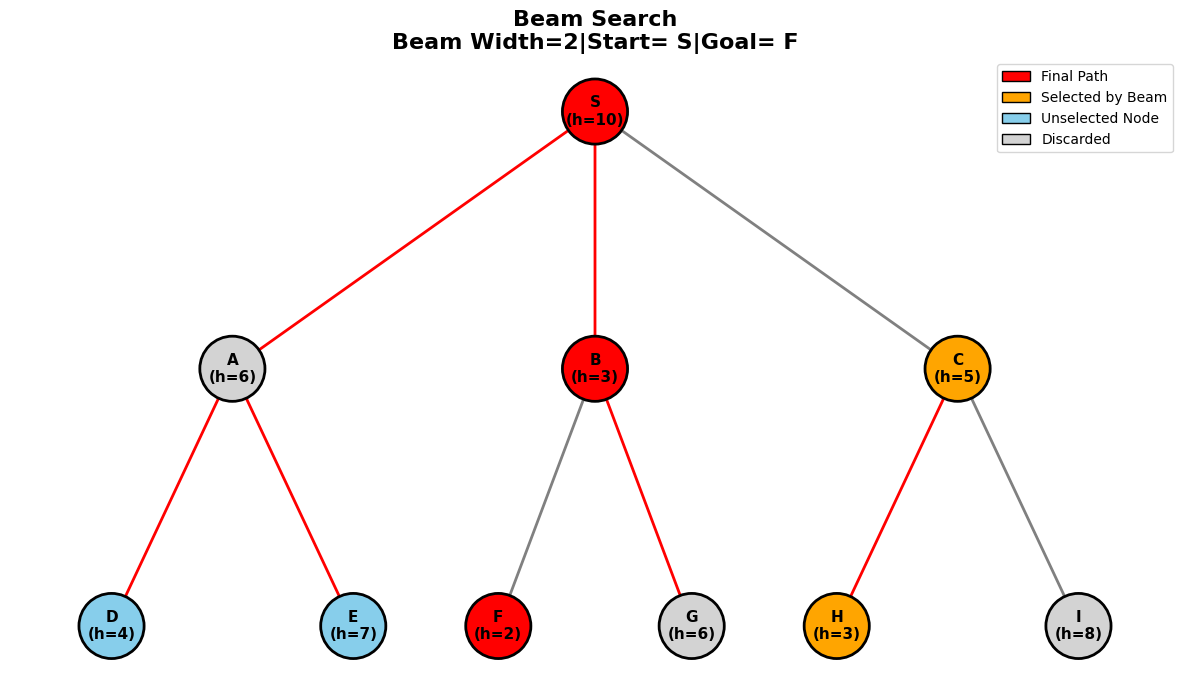

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
def beam_search(graph, heuristic, start, goal, beam_width):
  parent={start:None}
  beam=[start]
  selected_nodes={start}
  discarded_nodes=set()
  expanded_nodes=set()
  print("Beam Search")
  level=0
  while beam:
    print(f"\nLevel{level}")
    print("Current Beam:",beam)
    if goal in beam:
      print("\nGoal Found.")
      path=[]
      current=goal
      while current is not None:
        path.append(current)
        current=parent[current]
      path.reverse()
      print("Final Path:","->".join(path))
      return(
          path,
          selected_nodes,
          discarded_nodes,
          expanded_nodes
      )
    candidates=[]
    for node in beam:
      expanded_nodes.add(node)
      for neighbor in graph.get(node,[]):
        if neighbor not in selected_nodes:
          candidates.append(neighbor)
          if neighbor not in parent:
            parent[neighbor]=node
    candidates=list(dict.fromkeys(candidates))
    print("candidates:",candidates)
    candidates.sort(key=lambda x:heuristic[x])
    print("Sorted:",[(node,heuristic[node]) for node in candidates])
    new_beam=candidates[:beam_width]
    discarded=candidates[beam_width:]
    discarded_nodes.update(discarded)
    selected_nodes.update(new_beam)
    print("Selected:",[(node,heuristic[node]) for node in new_beam])
    print("Discarded:",[(node,heuristic[node]) for node in discarded])
    beam=new_beam
    level+=1
  print("\n Goal could not be reached.")
  return(
      None,
      selected_nodes,
      discarded_nodes,
      expanded_nodes
  )
graph={
    'S':['A','B','C'],
    'A':['D','E'],
    'B':['F','G'],
    'C':['H','I'],
    'D':[],
    'E':[],
    'F':[],
    'G':[],
    'H':[],
    'I':[]
}
heuristic={
    'S':10,
    'A':6,
    'B':3,
    'C':5,
    'D':4,
    'E':7,
    'F':2,
    'G':6,
    'H':3,
    'I':8
}
start='S'
goal='F'
beam_width=2
result=beam_search(graph,heuristic,start,goal,beam_width)
path,selected_nodes,discarded_nodes,expanded_nodes=result
G=nx.DiGraph()
for node in graph:
  G.add_node(node)
  for neighbor in graph[node]:
    G.add_edge(node,neighbor)
pos={
    'S':(0,3),
    'A':(-3,2),
    'B':(0,2),
    'C':(3,2),
    'D':(-4,1),
    'E':(-2,1),
    'F':(-0.8,1),
    'G':(0.8,1),
    'H':(2,1),
    'I':(4,1)
}
node_colors=[]
for node in G.nodes():
  if path and node in path:
    node_colors.append('red')
  elif node in discarded_nodes:
    node_colors.append('lightgray')
  elif node in selected_nodes:
    node_colors.append('orange')
  else:
    node_colors.append('skyblue')
edge_colors=[]
for edge in G.edges():
  u,v=edge
  if path and u in path and v in path:
    valid=False
    for i in range(len(path)-1):
      if path[i]==u and path[i+1]==v:
        valid=True
        break
    if valid:
      edge_colors.append('red')
    else:
      edge_colors.append('gray')
else:
   edge_colors.append('gray')
labels={}
for node in G.nodes():
  labels[node]=f"{node}\n(h={heuristic[node]})"
plt.figure(figsize=(12,7))
nx.draw_networkx_edges(G,pos,edge_color=edge_colors,arrows=True,arrowsize=20,width=2)
nx.draw_networkx_nodes(G,pos,node_color=node_colors,node_size=2200,edgecolors='black',linewidths=2)
nx.draw_networkx_labels(G,pos,labels=labels,font_size=11,font_weight='bold')
plt.title(
    f"Beam Search\n"
    f"Beam Width={beam_width}|"
    f"Start= {start}|Goal= {goal}",
    fontsize=16,
    fontweight='bold'
    )
from matplotlib.patches import Patch
legend_elements=[
    Patch(facecolor='red',edgecolor='black',label='Final Path'),
    Patch(facecolor='orange',edgecolor='black',label='Selected by Beam'),
    Patch(facecolor='skyblue',edgecolor='black',label='Unselected Node'),
    Patch(facecolor='lightgray',edgecolor='black',label='Discarded')
]
plt.legend(handles=legend_elements,loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()

